# AI Engineer 2 - Einführung PyTorch

### Aufgabe 1: Installieren Sie PyTorch

*Installieren Sie PyTorch gemäß der [Setup Dokumentation](https://pytorch.org/get-started/locally/)*



### Aufgabe 2: Implementieren Sie Ihr erstes Neuronales Netz

*Wählen Sie einen beliebigen einfachen Datensatz (bspw. Iris-binary, Vorbereitungszeit auf Klausur o.ä.) und trainieren Sie ein mehrschichtiges Neuronales Netz mit PyTorch. Zeigen Sie grafisch auf, dass Ihr Modell konvergiert.*

### Import Libraries

In [ ]:
from typing import Tuple

from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn import metrics

import torch
import torch.nn as nn
import torch.nn.functional as F

Vorbereitung der Daten

In [2]:
data = load_iris()

In [ ]:
# Laden und Vorbereiten der Daten wie gewohnt
data = load_iris()

# 2 Dimensionen wählen
x = data["data"][:, :2]

# Wir wollen nur 2 Klassen
y = np.where(data["target"] >= 1, 1, 0)

# Teilen des Datensatzes
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.33, random_state=45)

### Definiere eine Netzwerkarchitektur mit PyTorch

In [ ]:
class Net(nn.Module):

    def __init__(self, input_size, hidden_size1, hidden_size2):
        """
        Initialisierung der Neuronalen Netz Architektur mit festgelegten Anzahl an Schichten und
        zugehörigen Neuronen.
        TIPP: Manchmal hilft es, Batch Normalization Schichten einzubauen um die Inputs für die
        nächte Schicht zu standardisieren und das Training dadurch schneller und stabiler zu machen.
        """
        # Initialisiere das Modul aus nn.Module um die Eigenschaften zu übernehmen
        super().__init__()

        # Der Output der einen Schicht bestimmt die Größe des Inputs für die nächste
        self.fc1 = nn.Linear(input_size, hidden_size1)
        #self.b1 = nn.BatchNorm1d(n2)

        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        #self.b2 = nn.BatchNorm1d(n3)

        self.fc4 = nn.Linear(hidden_size2, 1)


    def forward(self, x):
        """
        Schleusen des Inputs durch die Schichten und Aktivierungsfunktionen.
        Wiedergabe des Outputs nach dem Propagating durch die gesamte Architektur.
        """
        # Wähle Relu Aktivierungsfunktion um die versteckten Schichten zu verknüpfen
        y = F.relu(self.fc1(x))
        y = F.relu(self.fc2(y))

        # Wähle eine Sigmoid Aktivierungsfunktion zur Klassifikation des Outputs
        y = F.sigmoid(self.fc4(y))

        return y


### Training a Neural Network

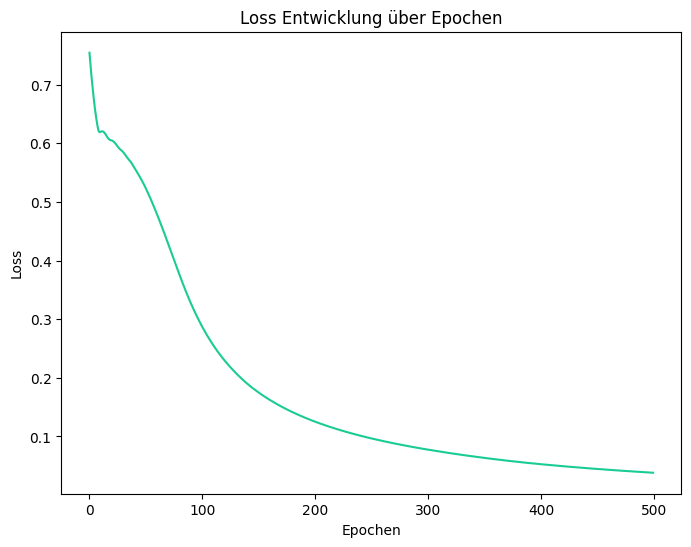

In [ ]:
# Initialisiere das NN Model
model = Net(input_size=x.shape[1], hidden_size1=8, hidden_size2=4)

# Initialisieren der Verlustfunktion und des Optimziers mit den Modelparamtern und der Lernrate
loss = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.009)

# Initialisiere Fehlerliste für die spätere Visualisierung
epoch_errors = []

# Trainiere das Modell in 500 Epochen
for epoch in range(500):
    # Für jede Epoche werden die Gradienten zurückgesetzt, Optimierung beginnt von vorn
    optimizer.zero_grad()

    # Berechne Fehler anhand der Trainingsdaten
    # Die Trainingsdaten müssen in die richtige Größe und Typ Tensor gebracht werden
    error = loss(model(torch.from_numpy(x_train).type(
        torch.FloatTensor)), torch.from_numpy(y_train).unsqueeze(1).type(torch.FloatTensor))

    # Speichern des Fehlers
    epoch_errors.append(error.item())

    # Berechne die Gradienten für alle Parameter
    error.backward()

    # Update aller Parameter anhand der Gradienten und Optimierungsformel
    optimizer.step()

# Darstellung des Fehlers über alle Epochen
plt.figure(figsize=(8, 6))
plt.plot(epoch_errors, color="#1ACC94")
plt.title('Loss Entwicklung über Epochen')
plt.xlabel('Epochen')
plt.ylabel('Loss')
plt.show()


In [6]:
def evaluation_measures(
    y_test: np.ndarray, y_pred: np.ndarray
) -> Tuple[str, Tuple[int, int, int], np.ndarray]:
    """Evaluiere die Vorhersagen anhand der wahren Ergebnisse.

    Args:
        y_test (np.ndarray): Wahre Ergebnisse.
        y_pred (np.ndarray): Vorhersagen des Modells.

    Returns:
        Tuple[str, Tuple[int, int, int], np.ndarray]: Klassifikationsreport, Tupel aus
            false-positive Rate, true positive Rate und dem AUC Wert der ROC Kurve und  die
            Confusionmatrix.
    """
    # Klassifikationsreport erstellen
    cr = metrics.classification_report(y_test, y_pred)

    # Die false poitive und true positiv rate wird für die ROC Kurve berechnet
    fpr, tpr, threshold = metrics.roc_curve(y_test, y_pred)

    # Berechne die Area under the curve (AUC) der ROC Kurve
    roc_auc = metrics.auc(fpr, tpr)

    # Confusionmatrix zeigt an wie viele Instanzen für welche Klassen richtig/falsch
    # klassifiziert wurden
    cm = metrics.confusion_matrix(y_test, y_pred)

    return cr, (fpr, tpr, roc_auc), cm


def plot_roc(auc_tuple: Tuple[int, int, int]) -> None:
    """Darstellung er ROC Kurve.

    Args:
        auc_tuple (Tuple[int, int, int]): Tupel aus false-positive Rate, true positive Rate und dem
            AUC Wert der ROC Kurve
    """
    # Entpacken des Tupels
    fpr, tpr, roc_auc = auc_tuple
    fig, ax = plt.subplots(figsize=(10, 5))
    plt.title("Receiver Operating Characteristic")

    # plot der Kurve und Hinzufügen eines Labels mit dem AUC Wert
    plt.plot(fpr, tpr, "b", label="AUC = %0.2f" % roc_auc)
    plt.legend(loc="lower right")
    plt.plot([0, 1], [0, 1], "r--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    plt.show()


def plot_cm(cm: np.ndarray) -> None:
    """Darstellung der Confusionmatrix.

    Args:
        cm (np.ndarray): Berechnete Werte für true negative, false positive, false negative und
            true positive.
    """
    disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Reds")
    plt.show()


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        31

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



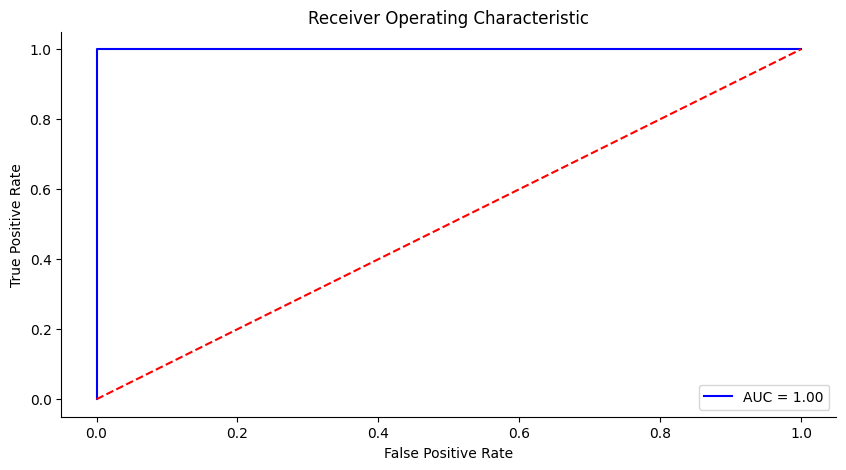

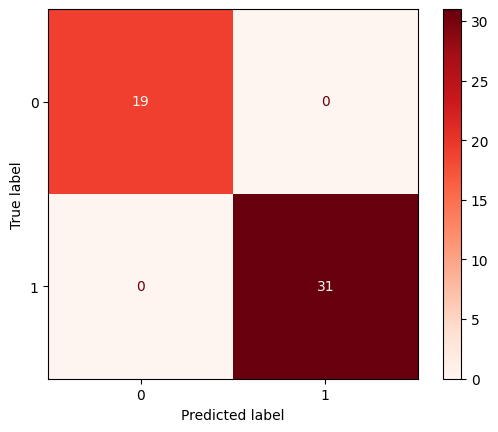

In [ ]:
# Klassifiziere die Testdaten
y_pred = model(torch.from_numpy(x_test).type(
    torch.FloatTensor)).detach().numpy()
y_pred = y_pred.reshape(y_pred.size)
y_true = np.copy(y_test)

# Binarisiere den Output
y_pred_binary = y_pred.round().astype(int)

# Evaluiere das Modell
cr, roc, cm = evaluation_measures(y_test, y_pred_binary)
print(cr)
plot_roc(roc)
plot_cm(cm)